In [ ]:
# ==========================================
# UEBA Challenge - Problema 1 (A + B)
# Autor: Alexis Pacek
# ==========================================

# ==========================================
# 📦 1. Imports
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, roc_auc_score

from sklearn.preprocessing import MinMaxScaler

import google.generativeai as genai
import os




# ==========================================
# 📥 2. Carga de datos
# ==========================================
df = pd.read_csv(r'src\data\user_logins.csv')

df['login_time'] = pd.to_datetime(df['login_time'])
df = df.sort_values(['user_id', 'login_time'])

# ==========================================
# 🔍 3. Feature Engineering
# ==========================================

# Proceso a agregar features comunes en la literatura de este problema


#agregar hora
# importancia: detectar comportamientos de uso horario
df['hour'] = df['login_time'].dt.hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)

# ------------------------------
# Velocidad de login
# ------------------------------
# Importancia: detectar actividad automatizada o sospechosa

df['time_diff'] = df.groupby('user_id')['login_time'].diff().dt.total_seconds()
df['time_diff'] = df['time_diff'].fillna(df['time_diff'].median())
df['time_diff_log'] = np.log1p(df['time_diff'])
# Diferencia temporal entre logins consecutivos (segundos)
# Se utiliza log-transform para reducir skewness


# ------------------------------
# 🌐 3.3 Rareza de IP
# ------------------------------
# Importancia: detectar IPs poco frecuentes

ip_counts = df.groupby(['user_id','ip_address']).size()
ip_freq = ip_counts / ip_counts.groupby(level=0).transform('sum')
df = df.join(ip_freq.rename('ip_freq'), on=['user_id','ip_address'])
df['ip_rarity'] = 1 - df['ip_freq']

# ------------------------------
# 💻 3.4 Rareza de dispositivo
# ------------------------------

device_counts = df.groupby(['user_id','device_type']).size()
device_freq = device_counts / device_counts.groupby(level=0).transform('sum')
df = df.join(device_freq.rename('device_freq'), on=['user_id','device_type'])
df['device_rarity'] = 1 - df['device_freq']

# ------------------------------
# 🔁 3.5 Cambios de contexto
# ------------------------------

df['ip_change'] = (df['ip_address'] != df.groupby('user_id')['ip_address'].shift()).astype(int)
df['device_change'] = (df['device_type'] != df.groupby('user_id')['device_type'].shift()).astype(int)

# ------------------------------
# 📊 3.6 Desvío horario real
# ------------------------------

mean_sin = df.groupby('user_id')['hour_sin'].transform('mean')
mean_cos = df.groupby('user_id')['hour_cos'].transform('mean')

df['hour_deviation'] = np.sqrt((df['hour_sin']-mean_sin)**2 + (df['hour_cos']-mean_cos)**2)

# ==========================================
# Nota:
# Se generaron múltiples features candidatas.
# Algunas (como login_velocity y device_change)
# fueron descartadas posteriormente por baja
# capacidad discriminativa en el análisis exploratorio.
# ==========================================



In [4]:
# ==========================================
#  Validación de datos
# ==========================================

nulls = df.isnull().sum()

print("Cantidad de valores nulos por columna:")
print(nulls)

if nulls.sum() == 0:
    print("No se detectaron valores nulos en el dataset")
else:
    print("Se detectaron valores nulos, revisar imputación")

print("\nNota:")
print("- 'time_diff' presenta valores nulos en el primer login de cada usuario (esperado)")
print("- Estos valores fueron imputados con la mediana antes de aplicar log-transform")
print("- 'time_diff_log' no presenta valores nulos")

Cantidad de valores nulos por columna:
user_id           0
login_time        0
ip_address        0
device_type       0
hour              0
hour_sin          0
hour_cos          0
time_diff         0
time_diff_log     0
ip_freq           0
ip_rarity         0
device_freq       0
device_rarity     0
ip_change         0
device_change     0
hour_deviation    0
dtype: int64
No se detectaron valores nulos en el dataset

Nota:
- 'time_diff' presenta valores nulos en el primer login de cada usuario (esperado)
- Estos valores fueron imputados con la mediana antes de aplicar log-transform
- 'time_diff_log' no presenta valores nulos



📊 Feature: time_diff_log

➡️ Estadísticas:
count    18941.000000
mean         9.682314
std          2.305874
min          0.000000
25%          8.583168
50%         10.389641
75%         11.343571
max         13.578751
Name: time_diff_log, dtype: float64

➡️ Percentiles:
0.01     0.000000
0.05     5.198497
0.50    10.389641
0.95    12.154890
0.99    12.701162
Name: time_diff_log, dtype: float64


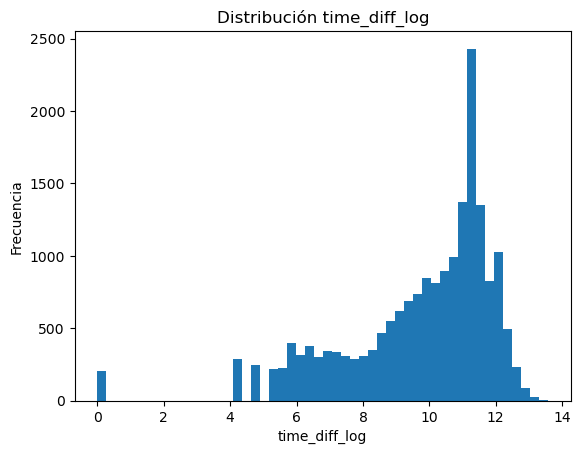


📊 Feature: ip_rarity

➡️ Estadísticas:
count    18941.000000
mean         0.489151
std          0.322248
min          0.174863
25%          0.250000
50%          0.324607
75%          0.974747
max          0.995726
Name: ip_rarity, dtype: float64

➡️ Percentiles:
0.01    0.191781
0.05    0.207254
0.50    0.324607
0.95    0.995025
0.99    0.995370
Name: ip_rarity, dtype: float64


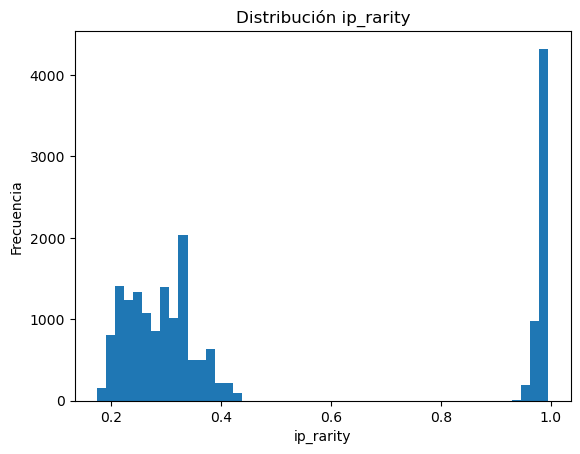


📊 Feature: device_rarity

➡️ Estadísticas:
count    18941.000000
mean         0.657600
std          0.053292
min          0.537313
25%          0.616352
50%          0.654255
75%          0.691542
max          0.804878
Name: device_rarity, dtype: float64

➡️ Percentiles:
0.01    0.545455
0.05    0.570552
0.50    0.654255
0.95    0.752427
0.99    0.787356
Name: device_rarity, dtype: float64


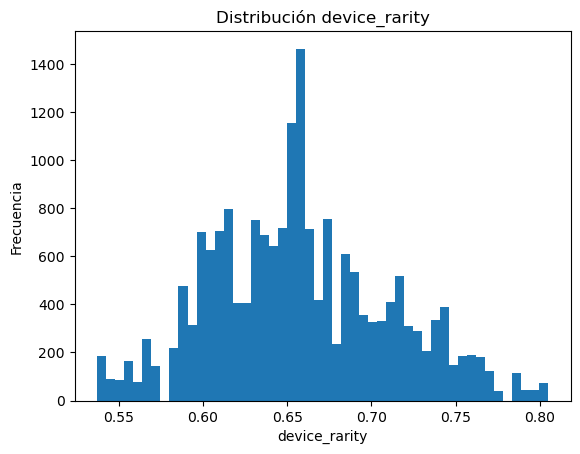


📊 Feature: hour_deviation

➡️ Estadísticas:
count    18941.000000
mean         0.789541
std          0.329175
min          0.130715
25%          0.546010
50%          0.854522
75%          1.017614
max          1.873771
Name: hour_deviation, dtype: float64

➡️ Percentiles:
0.01    0.132229
0.05    0.193713
0.50    0.854522
0.95    1.245247
0.99    1.576696
Name: hour_deviation, dtype: float64


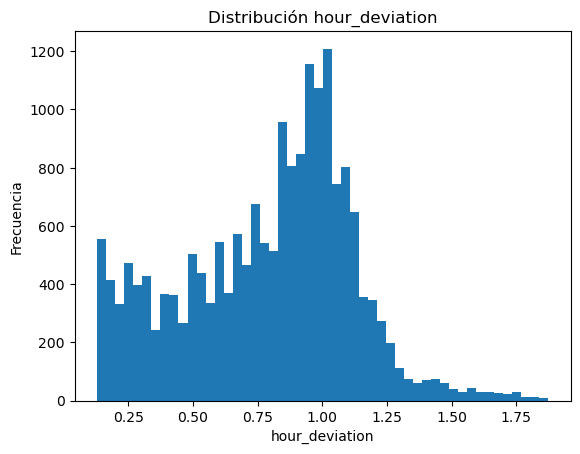


📊 Feature: ip_change

➡️ Estadísticas:
count    18941.000000
mean         0.465445
std          0.498818
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: ip_change, dtype: float64

➡️ Percentiles:
0.01    0.0
0.05    0.0
0.50    0.0
0.95    1.0
0.99    1.0
Name: ip_change, dtype: float64


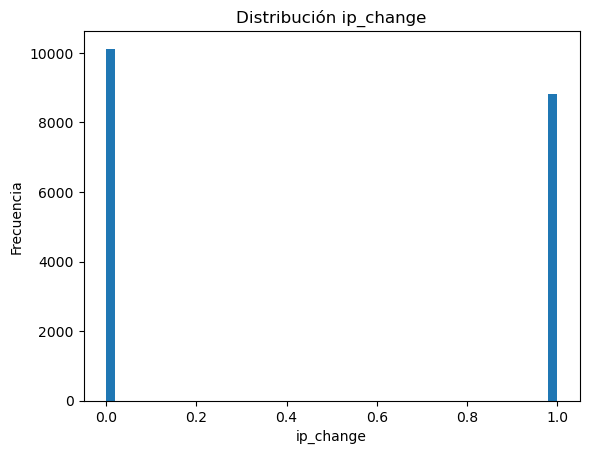


📊 Feature: device_change

➡️ Estadísticas:
count    18941.000000
mean         0.584182
std          0.492875
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: device_change, dtype: float64

➡️ Percentiles:
0.01    0.0
0.05    0.0
0.50    1.0
0.95    1.0
0.99    1.0
Name: device_change, dtype: float64


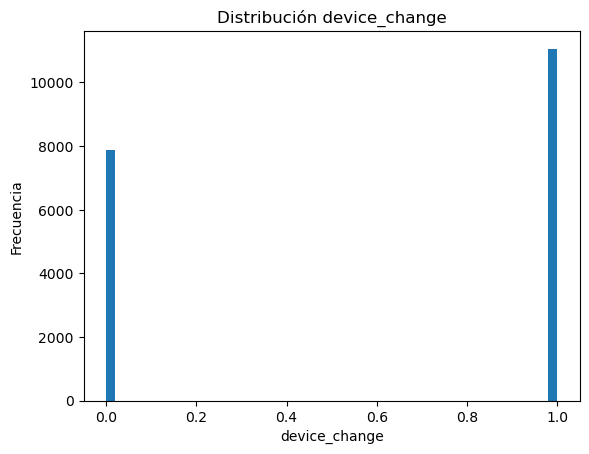


Conclusiones del análisis de features:

Features FUERTES:
- ip_rarity: alta capacidad de detectar IPs inusuales
- hour_deviation: captura desviaciones del patrón horario
- time_diff_log: identifica logins anormalmente rápidos

Features MEDIAS:
- ip_change: útil en combinación
- device_rarity: baja variabilidad, aporte limitado

Features DESCARTADAS:
- login_velocity: altamente sesgada por outliers
- device_change: comportamiento común, poco discriminativo



In [5]:
# ==========================================
# 📊 EDA por feature
# ==========================================

# Features analizadas
features_all = [
    'time_diff_log',
    'ip_rarity',
    'device_rarity',
    'hour_deviation',
    'ip_change',
    'device_change'
]

for f in features_all:
    print(f"\n============================")
    print(f"📊 Feature: {f}")
    print("============================")
    
    print("\n➡️ Estadísticas:")
    print(df[f].describe())
    
    print("\n➡️ Percentiles:")
    print(df[f].quantile([0.01,0.05,0.5,0.95,0.99]))
    
    plt.figure()
    plt.hist(df[f], bins=50)
    plt.title(f'Distribución {f}')
    plt.xlabel(f)
    plt.ylabel("Frecuencia")
    plt.show()

# ==========================================
# 🧠 Conclusión del EDA
# ==========================================

print("""
Conclusiones del análisis de features:

Features FUERTES:
- ip_rarity: alta capacidad de detectar IPs inusuales
- hour_deviation: captura desviaciones del patrón horario
- time_diff_log: identifica logins anormalmente rápidos

Features MEDIAS:
- ip_change: útil en combinación
- device_rarity: baja variabilidad, aporte limitado

Features DESCARTADAS:
- login_velocity: altamente sesgada por outliers
- device_change: comportamiento común, poco discriminativo
""")

In [6]:
# ==========================================
#  Análisis de geolocalización IP
# ==========================================

import ipaddress

def is_private_ip(ip):
    try:
        return ipaddress.ip_address(ip).is_private
    except:
        return True

df['is_private_ip'] = df['ip_address'].apply(is_private_ip)

private_ratio = df['is_private_ip'].mean()

print(f"% IPs privadas: {private_ratio:.2%}")

# Conclusión:
# La gran mayoría de las IPs (~97%) son privadas,
# por lo que no es posible aplicar geolocalización
# confiable (ej. GeoLite2). Esta línea de análisis
# se descarta.

df = df.drop(columns=['is_private_ip'])

% IPs privadas: 96.96%



➡️ Estadísticas:
count    18941.000000
mean        19.295919
std          8.265283
min          1.000000
25%         16.000000
50%         21.000000
75%         25.000000
max         30.000000
Name: ip_user_count, dtype: float64

➡️ Percentiles:
0.01     1.0
0.05     1.0
0.50    21.0
0.95    29.0
0.99    30.0
Name: ip_user_count, dtype: float64


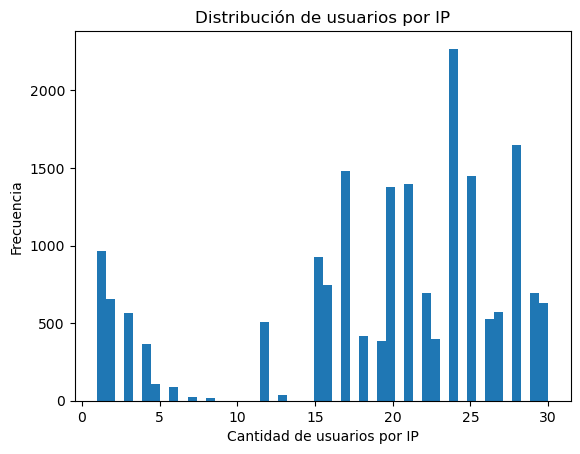

In [7]:
# ==========================================
#  Análisis de IPs compartidas
# ==========================================

# Cantidad de usuarios por IP
ip_user_count = df.groupby('ip_address')['user_id'].nunique()
df = df.join(ip_user_count.rename('ip_user_count'), on='ip_address')

print("\n➡️ Estadísticas:")
print(df['ip_user_count'].describe())

print("\n➡️ Percentiles:")
print(df['ip_user_count'].quantile([0.01,0.05,0.5,0.95,0.99]))

plt.figure()
plt.hist(df['ip_user_count'], bins=50)
plt.title("Distribución de usuarios por IP")
plt.xlabel("Cantidad de usuarios por IP")
plt.ylabel("Frecuencia")
plt.show()

# Conclusión:
# Existen IPs compartidas por múltiples usuarios.
# Valores altos pueden indicar proxies, VPNs o redes compartidas,
# lo cual puede ser relevante en la detección de anomalías.

In [8]:
# ==========================================
#  Features exploradas (descartadas)
# ==========================================

"""
Durante el análisis se exploraron features adicionales relacionadas
con comportamiento de IP:

- ip_is_rare: IP utilizada por un solo usuario
- ip_is_massive: IP compartida por muchos usuarios
- suspicious_ip: combinación de rareza y baja frecuencia
- rule_ip: anomalía basada en percentiles por usuario

Conclusión:
Estas variables no fueron incluidas en el modelo final ya que no
aportaron mejora significativa en la capacidad discriminativa respecto
a features más robustas como ip_rarity y hour_deviation.
"""

'\nDurante el análisis se exploraron features adicionales relacionadas\ncon comportamiento de IP:\n\n- ip_is_rare: IP utilizada por un solo usuario\n- ip_is_massive: IP compartida por muchos usuarios\n- suspicious_ip: combinación de rareza y baja frecuencia\n- rule_ip: anomalía basada en percentiles por usuario\n\nConclusión:\nEstas variables no fueron incluidas en el modelo final ya que no\naportaron mejora significativa en la capacidad discriminativa respecto\na features más robustas como ip_rarity y hour_deviation.\n'

In [9]:
# ==========================================
#  Construcción de señales de anomalía
# ==========================================

# Nota:
# Se utilizan percentiles por usuario para capturar comportamiento individual (UEBA)

# --- IP anomaly ---
p90_ip = df.groupby('user_id')['ip_rarity'].transform(lambda x: x.quantile(0.90))

df['ip_anomaly'] = (
    (df['ip_rarity'] > p90_ip) &
    (df['ip_change'] == 1)
).astype(int)

# --- Time anomaly ---
p5_time = df.groupby('user_id')['time_diff'].transform(lambda x: x.quantile(0.05))

df['time_anomaly'] = (df['time_diff'] < p5_time).astype(int)

# --- Hour anomaly ---
# Threshold global (la métrica ya está normalizada por usuario)

df['hour_anomaly'] = (
    df['hour_deviation'] > df['hour_deviation'].quantile(0.95)
).astype(int)

# --- Contexto ---
df['ip_shared_extreme'] = (
    df['ip_user_count'] >= df['ip_user_count'].quantile(0.95)
).astype(int)

df['ip_consistency'] = df.groupby('user_id')['ip_address'].transform('nunique')

# --- Score final ---
df['risk_score'] = (
    2 * df['ip_anomaly'] +
    1 * df['time_anomaly'] +
    1 * df['hour_anomaly']
)

In [ ]:
# ==========================================
# Label final (rule-based)
# ==========================================

threshold = df['risk_score'].quantile(0.95)
df['label_rule'] = (df['risk_score'] >= threshold).astype(int)

# Se utiliza percentil 95 para definir anomalías,
# lo que permite identificar el comportamiento más extremo
# sin depender de umbrales arbitrarios.



# ==========================================
#  Generación de reportes con Gemini (UEBA)
# ==========================================

# Configurar API KEY
api_key = os.getenv("GEMINI_API_KEY")
model = genai.GenerativeModel("gemini-3-flash-preview")


# ==========================================
# Selección de usuarios (diversidad)
# ==========================================

user_scores = df.groupby('user_id')['label_rule'].mean().sort_values()

# 1 usuario muy anómalo
user_high = user_scores.tail(1).index[0]

# 1 usuario promedio
user_mid = user_scores.index[len(user_scores)//2]

# 1 usuario normal
user_low = user_scores.head(1).index[0]

selected_users = [user_high, user_mid, user_low]

print("Usuarios seleccionados:", selected_users)


# ==========================================
# Construcción del summary
# ==========================================

def build_user_summary(df, user_id):
    df_u = df[df['user_id'] == user_id]
    
    summary = {
        "user_id": user_id,
        "total_logins": int(len(df_u)),
        
        #  decisión final
        "decision": "ALERT" if df_u['label_rule'].mean() > 0.05 else "NO ALERT",
        "anomaly_rate": float(df_u['label_rule'].mean()),
        
        #  señales del modelo
        "ip_anomaly_events": int(df_u['ip_anomaly'].sum()),
        "time_anomaly_events": int(df_u['time_anomaly'].sum()),
        "hour_anomaly_events": int(df_u['hour_anomaly'].sum()),
        
        # contexto
        "unique_ips": int(df_u['ip_address'].nunique()),
        "ip_consistency": int(df_u['ip_consistency'].iloc[0]),
        
        # extremos
        "max_ip_rarity": float(df_u['ip_rarity'].max()),
        "max_hour_deviation": float(df_u['hour_deviation'].max())
    }
    
    return summary


# ==========================================
# Generación de reporte con Gemini
# ==========================================

def generate_report(summary):
    prompt = f"""
Eres un analista de ciberseguridad explicando alertas generadas por un sistema UEBA.

El sistema utiliza las siguientes reglas:
- ip_anomaly: IP inusual + cambio de IP
- time_anomaly: logins inusualmente rápidos
- hour_anomaly: horarios de login inusuales

IMPORTANTE:
La decisión ya fue tomada por el sistema.

Decisión: {summary["decision"]}

Datos del usuario:
{summary}

Tareas:
1. Explicar por qué el sistema tomó esta decisión
2. Describir qué comportamientos activaron las reglas
3. Proponer posibles explicaciones (legítimas o maliciosas)
4. Asignar un nivel de riesgo (Bajo, Medio, Alto)

NO cambies la decisión. Solo explícalo.
Escribe de forma clara, profesional y concisa.
"""
    
    response = model.generate_content(prompt)
    return response.text


# ==========================================
# Ejecutar reportes
# ==========================================

for user in selected_users:
    summary = build_user_summary(df, user)
    report = generate_report(summary)
    
    print("\n" + "="*80)
    print(f" Reporte para {user}")
    print("="*80)
    print(report)



Usuarios seleccionados: ['user_79', 'user_84', 'user_45']

 Reporte para user_79
### Reporte de Análisis UEBA: Alerta de Comportamiento de Usuario

**ID de Usuario:** `user_79`
**Decisión del Sistema:** **ALERT** (Alerta)
**Nivel de Riesgo Sugerido:** **Medio**

---

#### 1. Explicación de la decisión
El sistema ha emitido una alerta debido a una desviación significativa en el patrón de comportamiento habitual del usuario. Con un **tasa de anomalía del 17.9%**, casi uno de cada cinco eventos registrados presenta irregularidades. La decisión se fundamenta principalmente en la acumulación de eventos fuera de horario y la velocidad inusual entre sesiones, lo que sugiere una actividad que no coincide con el perfil histórico establecido para esta cuenta.

#### 2. Comportamientos que activaron las reglas
La alerta fue disparada por la activación recurrente de dos reglas específicas:

*   **hour_anomaly (24 eventos):** Esta es la mayor fuente de sospecha. El usuario ha realizado 24 accesos en

In [ ]:
print("Distribución de anomalías:")
print(df['label_rule'].value_counts(normalize=True))
# ==========================================
# Selección de features
# ==========================================

FEATURES = [
    'time_diff_log',
    'ip_rarity',
    'hour_deviation',
    'ip_consistency',
    'ip_anomaly',
    'ip_shared_extreme'
]


X = df[FEATURES].copy()


# ==========================================
#  Normalización
# ==========================================


scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


# ==========================================
#  Modelo ML
# ==========================================


model = IsolationForest(
    contamination=df['label_rule'].mean(),
    random_state=42
)

model.fit(X_scaled)

# SCORE CONTINUO 
df['anomaly_score_ml'] = -model.decision_function(X_scaled)



# ==========================================
# Calibración POR USUARIO (UEBA)
# ==========================================

# Threshold por usuario
user_thresholds = df.groupby('user_id')['anomaly_score_ml'].quantile(0.95)
# Calibración por usuario:
# Se calcula un threshold específico por usuario (p95),
# permitiendo detectar anomalías relativas al comportamiento individual
# y evitando sesgos entre usuarios con distintos patrones de uso.

df['user_threshold'] = df['user_id'].map(user_thresholds)

# Manejo de usuarios con pocos datos
user_counts = df['user_id'].value_counts()


# Predicción final UEBA
df['anomaly_user'] = (
    df['anomaly_score_ml'] > df['user_threshold']
).astype(int)


# ==========================================
# Comparaciones
# ==========================================



print("\nComparación reglas vs modelo por usuario:")
print(classification_report(df['label_rule'], df['anomaly_user']))


# ==========================================
# Importancia de features
# ==========================================

print(f"% anomalías (rule):   {df['label_rule'].mean():.4%}")
print(f"% anomalías (user):   {df['anomaly_user'].mean():.4%}")

importance = df.groupby('label_rule')[FEATURES].mean().T
importance['diff'] = importance[1] - importance[0]

print("\nImportancia de features:")
print(importance.sort_values('diff', ascending=False))


# ==========================================
# Diagnóstico UEBA 
# ==========================================

print("\nDistribución de anomalías por usuario:")
print(df.groupby('user_id')['anomaly_user'].mean().describe())

# Nota:
# El modelo tiende a detectar menos anomalías que las reglas,
# lo cual sugiere que actúa como un filtro adicional,
# reduciendo posibles falsos positivos generados por el enfoque rule-based.

# ==========================================
#  Análisis adicional: Experimentos
# ==========================================

In [11]:
# Nota:
# Esta función permite evaluar la sensibilidad del modelo a distintas combinaciones de features,
# validando la robustez del enfoque propuesto.

def run_experiment(df, FEATURES, label_col='label_rule'):
    
    print("\n" + "="*50)
    print(f"Features usadas: {FEATURES}")
    print("="*50)
    
    df_tmp = df.copy()
    
    # Selección
    X = df_tmp[FEATURES].copy()
    
    # Escalado
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Modelo
    model = IsolationForest(
        contamination=df_tmp[label_col].mean(),
        random_state=42
    )
    
    model.fit(X_scaled)
    
    # Score continuo
    df_tmp['anomaly_score_ml_tmp'] = -model.decision_function(X_scaled)
    
    # Threshold por usuario
    user_thresholds = df_tmp.groupby('user_id')['anomaly_score_ml_tmp'].quantile(0.95)
    df_tmp['user_threshold_tmp'] = df_tmp['user_id'].map(user_thresholds)
    
    # Predicción final
    df_tmp['anomaly_user_tmp'] = (
        df_tmp['anomaly_score_ml_tmp'] > df_tmp['user_threshold_tmp']
    ).astype(int)
    
    # Métricas
    print("\n📊 Métricas:")
    print(classification_report(df_tmp[label_col], df_tmp['anomaly_user_tmp']))
    
    print(f"% anomalías (modelo): {df_tmp['anomaly_user_tmp'].mean():.4%}")
    
    # Importancia (proxy)
    importance = df_tmp.groupby(label_col)[FEATURES].mean().T
    importance['diff'] = importance[1] - importance[0]
    
    print("\n📊 Importancia de features:")
    print(importance.sort_values('diff', ascending=False))

In [ ]:
# ==========================================
#  Experimento 1: Features principales
# ==========================================
# Se evalúan las features más fuertes identificadas en el EDA:
# - time_diff_log
# - ip_rarity
# - hour_deviation

FEATURES_A = [
    'time_diff_log',
    'ip_rarity',
    'hour_deviation'
]

run_experiment(df, FEATURES_A)


Features usadas: ['time_diff_log', 'ip_rarity', 'hour_deviation']

📊 Métricas:
              precision    recall  f1-score   support

           0       0.93      0.98      0.96     17111
           1       0.64      0.35      0.45      1830

    accuracy                           0.92     18941
   macro avg       0.79      0.66      0.70     18941
weighted avg       0.91      0.92      0.91     18941

% anomalías (modelo): 5.1792%

📊 Importancia de features:
label_rule             0         1      diff
hour_deviation  0.757158  1.092328  0.335170
ip_rarity       0.486487  0.514063  0.027576
time_diff_log   9.940441  7.268751 -2.671690


In [ ]:
# Experimento 2: + contexto de IP
FEATURES_B = [
    'time_diff_log',
    'ip_rarity',
    'hour_deviation',
    'ip_consistency'
]

run_experiment(df, FEATURES_B)


Features usadas: ['time_diff_log', 'ip_rarity', 'hour_deviation', 'ip_consistency']

📊 Métricas:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     17111
           1       0.60      0.32      0.42      1830

    accuracy                           0.91     18941
   macro avg       0.76      0.65      0.69     18941
weighted avg       0.90      0.91      0.90     18941

% anomalías (modelo): 5.2004%

📊 Importancia de features:
label_rule              0          1      diff
hour_deviation   0.757158   1.092328  0.335170
ip_consistency  38.304716  38.337158  0.032442
ip_rarity        0.486487   0.514063  0.027576
time_diff_log    9.940441   7.268751 -2.671690


In [ ]:
# ==========================================
# 🔬 Experimento 2: Features extendidas (contexto de IP)
# ==========================================
# Se incorporan features adicionales relacionadas con comportamiento de IP:
# - ip_consistency: diversidad de IPs por usuario
# - ip_anomaly: eventos con IP inusual + cambio de IP
# - ip_shared_extreme: IPs altamente compartidas
#
# Objetivo:
# Evaluar si el contexto de red mejora la detección de anomalías.

FEATURES_EXTENDED = [
    'time_diff_log',
    'ip_rarity',
    'hour_deviation',
    'ip_consistency',
    'ip_anomaly',
    'ip_shared_extreme'
]

run_experiment(df, FEATURES_EXTENDED)


Features usadas: ['time_diff_log', 'ip_rarity', 'hour_deviation', 'ip_consistency', 'ip_anomaly', 'ip_shared_extreme']

📊 Métricas:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     17111
           1       0.61      0.32      0.42      1830

    accuracy                           0.91     18941
   macro avg       0.77      0.65      0.69     18941
weighted avg       0.90      0.91      0.90     18941

% anomalías (modelo): 5.1581%

📊 Importancia de features:
label_rule                 0          1      diff
hour_deviation      0.757158   1.092328  0.335170
ip_consistency     38.304716  38.337158  0.032442
ip_rarity           0.486487   0.514063  0.027576
ip_anomaly          0.000000   0.009290  0.009290
ip_shared_extreme   0.070890   0.063388 -0.007502
time_diff_log       9.940441   7.268751 -2.671690


In [ ]:
print('El contexto de red aporta información relevante en la detección de anomalías')

El contexto de red aporta información relevante en la detección de anomalías


In [ ]:
# ==========================================
#  Análisis de sensibilidad: ponderación de reglas
# ==========================================
# Se evalúa el impacto de distintas ponderaciones en el risk_score
# para analizar la robustez del sistema.

def run_weight_experiment(df, w_ip, w_time, w_hour, FEATURES):
    
    print("\n" + "="*60)
    print(f"Pesos -> ip:{w_ip}, time:{w_time}, hour:{w_hour}")
    print("="*60)
    
    df_tmp = df.copy()
    
    # Construcción del label
    df_tmp['risk_score_tmp'] = (
        w_ip * df_tmp['ip_anomaly'] +
        w_time * df_tmp['time_anomaly'] +
        w_hour * df_tmp['hour_anomaly']
    )
    
    threshold = df_tmp['risk_score_tmp'].quantile(0.95)
    df_tmp['label_tmp'] = (df_tmp['risk_score_tmp'] >= threshold).astype(int)
    
    print(f"% anomalías (label): {df_tmp['label_tmp'].mean():.4%}")
    
    # Modelo
    X = df_tmp[FEATURES].copy()
    
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    
    model = IsolationForest(
        contamination=df_tmp['label_tmp'].mean(),
        random_state=42
    )
    
    model.fit(X_scaled)
    
    df_tmp['anomaly_score_ml_tmp'] = -model.decision_function(X_scaled)
    
    # Threshold por usuario
    user_thresholds = df_tmp.groupby('user_id')['anomaly_score_ml_tmp'].quantile(0.95)
    df_tmp['user_threshold_tmp'] = df_tmp['user_id'].map(user_thresholds)
    
    df_tmp['anomaly_user_tmp'] = (
        df_tmp['anomaly_score_ml_tmp'] > df_tmp['user_threshold_tmp']
    ).astype(int)
    
    # Métricas
    print("\n📊 Métricas:")
    print(classification_report(df_tmp['label_tmp'], df_tmp['anomaly_user_tmp']))
    
    print(f"% anomalías (modelo): {df_tmp['anomaly_user_tmp'].mean():.4%}")
    
    # Importancia
    importance = df_tmp.groupby('label_tmp')[FEATURES].mean().T
    importance['diff'] = importance[1] - importance[0]
    
    print("\n📊 Importancia de features:")
    print(importance.sort_values('diff', ascending=False))
    

    
 

In [ ]:
# ==========================================
#  Experimento de sensibilidad (pesos)
# ==========================================
# Se evalúa el impacto de la ponderación del risk_score
# sobre la detección de anomalías.

run_weight_experiment(
    df,
    w_ip=2,
    w_time=1,
    w_hour=1,
    FEATURES=FEATURES
)


Pesos -> ip:2, time:1, hour:1
% anomalías (label): 9.6616%

📊 Métricas:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     17111
           1       0.61      0.32      0.42      1830

    accuracy                           0.91     18941
   macro avg       0.77      0.65      0.69     18941
weighted avg       0.90      0.91      0.90     18941

% anomalías (modelo): 5.1581%

📊 Importancia de features:
label_tmp                  0          1      diff
hour_deviation      0.757158   1.092328  0.335170
ip_consistency     38.304716  38.337158  0.032442
ip_rarity           0.486487   0.514063  0.027576
ip_anomaly          0.000000   0.009290  0.009290
ip_shared_extreme   0.070890   0.063388 -0.007502
time_diff_log       9.940441   7.268751 -2.671690


In [ ]:
run_weight_experiment(df, w_ip=1, w_time=2, w_hour=1, FEATURES=FEATURES)


Pesos -> ip:1, time:2, hour:1
% anomalías (label): 9.6616%

📊 Métricas:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     17111
           1       0.61      0.32      0.42      1830

    accuracy                           0.91     18941
   macro avg       0.77      0.65      0.69     18941
weighted avg       0.90      0.91      0.90     18941

% anomalías (modelo): 5.1581%

📊 Importancia de features:
label_tmp                  0          1      diff
hour_deviation      0.757158   1.092328  0.335170
ip_consistency     38.304716  38.337158  0.032442
ip_rarity           0.486487   0.514063  0.027576
ip_anomaly          0.000000   0.009290  0.009290
ip_shared_extreme   0.070890   0.063388 -0.007502
time_diff_log       9.940441   7.268751 -2.671690


In [ ]:
run_weight_experiment(df, w_ip=1, w_time=1, w_hour=1, FEATURES=FEATURES)

    # Nota 
print("\nNota:")
print("El uso de percentiles hace que el sistema sea robusto a cambios en los pesos.")


Pesos -> ip:1, time:1, hour:1
% anomalías (label): 9.6616%

📊 Métricas:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     17111
           1       0.61      0.32      0.42      1830

    accuracy                           0.91     18941
   macro avg       0.77      0.65      0.69     18941
weighted avg       0.90      0.91      0.90     18941

% anomalías (modelo): 5.1581%

📊 Importancia de features:
label_tmp                  0          1      diff
hour_deviation      0.757158   1.092328  0.335170
ip_consistency     38.304716  38.337158  0.032442
ip_rarity           0.486487   0.514063  0.027576
ip_anomaly          0.000000   0.009290  0.009290
ip_shared_extreme   0.070890   0.063388 -0.007502
time_diff_log       9.940441   7.268751 -2.671690

Nota:
El uso de percentiles hace que el sistema sea robusto a cambios en los pesos.


El porcentaje de anomalías puede variar ligeramente debido a la naturaleza discreta del risk score, ya que múltiples eventos pueden compartir el mismo valor y ser incluidos simultáneamente al aplicar un umbral basado en percentiles.

Se evaluó la sensibilidad del modelo ante distintas ponderaciones del risk score, observando que los resultados se mantienen estables. Esto indica que la detección de anomalías es robusta y no depende de una configuración específica de pesos, sino de la consistencia de las señales utilizadas.